# Объявление библиотек

In [25]:
import numpy as np
from matplotlib import pyplot as plt
import cv2 

# Загрузка видео

In [26]:
cap = cv2.VideoCapture('mouse.avi') # это функция OpenCV, которая создает объект для чтения видео
# Объект cap позволяет читать кадры из этого видео, получать информацию о нем (размер, FPS и т.д.) и управлять воспроизведением

# Считываем первый кадр

In [35]:
if not cap.isOpened(): # возвращает True, если видеофайл успешно открыт и объект захвата готов к работе
    print("Не удалось открыть видео")
    exit()
success, img1 = cap.read() # cap.read() читает следующий кадр из видеофайла
# success - True, если кадр успешно прочитан, False если достигнут конец видео или произошла ошибка
# img1 — прочитанный кадр в виде массива NumPy (матрица пикселей)
img = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) # функция для преобразования цветовой модели изображения
# Это необходимо, потому что библиотека Matplotlib (которая будет использоваться для отображения) ожидает изображения в формате RGB
# Если этого не сделать, цвета на отображаемой картинке будут искажены (синий и красный поменяются местами)

# Визуализируем первый кадр

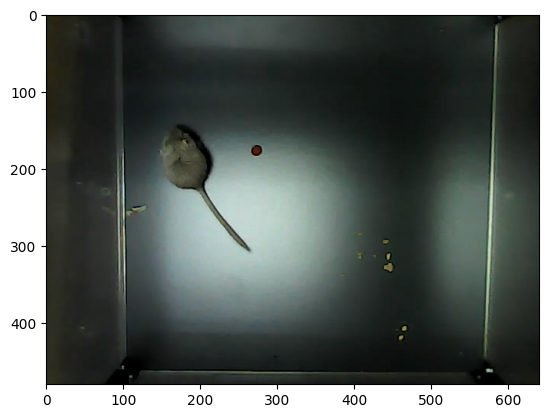

In [36]:
plt.imshow(img) # функция библиотеки Matplotlib, которая выводит изображение на экран

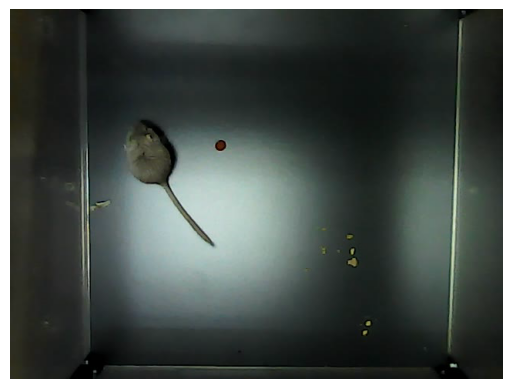

In [37]:
# Отображаем изображение
plt.imshow(img)
plt.axis('off')  # Отключаем оси 
# Сохраняем
plt.savefig('mice.png', dpi=300, bbox_inches='tight') # dpi=300 — разрешение в точках на дюйм
# bbox_inches='tight' — автоматически обрезает пустые поля вокруг содержимого
# Это гарантирует, что сохраненное изображение будет точно обрезано по границам картинки, без лишних белых полей
plt.show()

# Преобразование видеофайла в последовательность изображений

In [6]:
# Инициализируем счетчик кадров, начинаем с 1
i=1

imgs = [] # пустой список Python, который будет использоваться для накопления всех обработанных кадров 
# Каждый кадр будет добавлен в этот список для последующей обработки или анализа

while True: # while True создает цикл, который будет выполняться до тех пор, пока не встретит команду break
    success, img = cap.read() # cap.read() читает один кадр из видеофайла
    # success — True если кадр успешно прочитан, False если достигнут конец видео или произошла ошибка

    # Проверка валидности прочитанного кадра
    if not success or img is None or img.size == 0: # not success — если чтение не удалось (конец видео или ошибка)
        # img is None — если кадр не существует, img.size == 0 — если массив пустой 
        print(f"Конец видео или ошибка чтения на кадре {i}")
        break
    
    # Преобразование кадра в оттенки серого
    # Для уменьшения объема данных, упрощения последующей обработки (детекции движения), повышения скорости обработки
    img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    imgs.append(img_grey) # Метод append() добавляет преобразованный кадр img_grey в конец списка imgs

    # Увеличивает переменную i на 1
    i += 1 # Это позволяет отслеживать номер следующего кадра и выводить корректную информацию при возникновении ошибки

cap.release() # cap.release() закрывает видеофайл и освобождает все системные ресурсы, связанные с объектом VideoCapture
# Это для предотвращения утечек памяти и корректного завершения работы с файлом
print(f"Загружено {len(imgs)} кадров")

Конец видео или ошибка чтения на кадре 6076
Загружено 6075 кадров


# Обращаемся 3525 элементу массива и визуализируем кадр

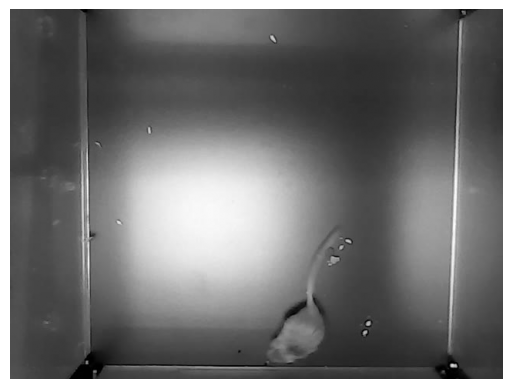

In [38]:
plt.imshow(imgs[3525], cmap='gray') # то есть 3001-й кадр, так как индексация в Python начинается с 0
# cmap='gray' — параметр цветовой карты (colormap), который указывает, что изображение следует отображать в оттенках серого
# Поскольку imgs содержит изображения в оттенках серого (одноканальные), параметр cmap='gray' обязателен 
# Без него Matplotlib может отобразить изображение в псевдоцветах (например, в фиолетово-желтой гамме по умолчанию)

plt.axis('off')  # Отключаем оси

plt.savefig('MiceGray.png', dpi=300, bbox_inches='tight')
plt.show()

# Модель усредненного фона

In [8]:
def sr_mod_fon (arr_image): # принимает один параметр arr_image (массив изображений)
# функция предназначена для вычисления модели фона путем усреднения серии кадров
  mod_fon = np.zeros(arr_image[1].shape, dtype='uint8') # создает массив, заполненный нулями
# arr_image[1].shape — берет форму (размеры) второго изображения в списке (индекс 1)
# dtype='uint8' — тип данных: 8-битные целые числа без знака (0-255)
    
  sum=np.zeros([480,640]) # создает двумерный массив размером 480×640, заполненный нулями
    # Здесь будут накапливаться суммы значений пикселей по всем кадрам

  for k in range(len(arr_image)-10): # Цикл по изображениям (исключая последние 10)
      # Это делается для того, чтобы игнорировать возможные движения или объекты, которые могли появиться в конце видео

    image=arr_image[k] # Берет k-ое изображение из массива arr_image и присваивает переменной image для удобства работы в текущей итерации цикла
  # Извлечение текущего изображения
      
    for i in range(len(image)): # цикл по строкам изображения
  # len(image) возвращает количество строк (высоту) изображения. Для каждого значения i (номера строки) будет выполняться внутренний цикл
      for j in range(len(image[i])): # цикл по столбцам изображения
   # len(image[i]) возвращает количество столбцов (ширину) в i-ой строке. Переменная j перебирает все столбцы текущей строки
        sum[i,j]=sum[i,j]+image[i,j] # Накопление суммы значений пикселей
          # sum[i,j] — текущая накопленная сумма для пикселя с координатами (i, j), image[i,j] — значение текущего пикселя (яркость от 0 до 255)
          # К накопленной сумме добавляется значение текущего пикселя
          # В результате после завершения всех итераций внешнего цикла в массиве sum будет сумма значений каждого пикселя по всем обработанным кадрам

  sum=sum/k # Вычисление среднего арифметического
    # делит каждый элемент массива sum на количество обработанных кадров k
    # После этого sum содержит среднее значение каждого пикселя по всем кадрам
  return sum # Функция возвращает массив sum, который теперь содержит усредненную модель фона

In [9]:
amt=sr_mod_fon(imgs) # Вызов функции для вычисления модели фона
# sr_mod_fon(imgs) — вызывается ранее определенная функция, которая принимает список изображений imgs (все кадры видео в оттенках серого)
# Функция возвращает массив средних значений пикселей (модель фона) в виде чисел с плавающей точкой

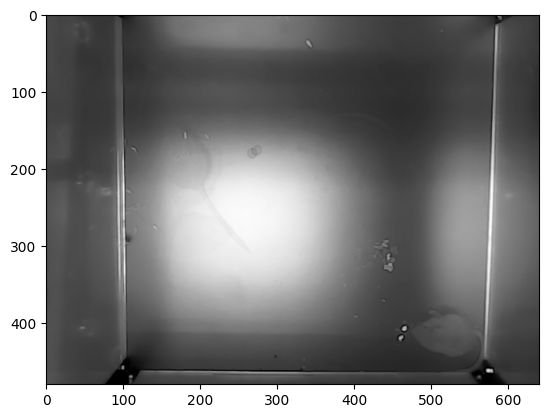

In [10]:
new=np.uint8(amt) # преобразует массив amt к типу uint8 (диапазон 0-255)
# plt.imshow() ожидает данные в диапазоне 0-255 для корректного отображения. Исходные изображения были в формате uint8
# Значения с плавающей точкой округляются до целых
plt.imshow(new, cmap='gray') # Отображение модели фона

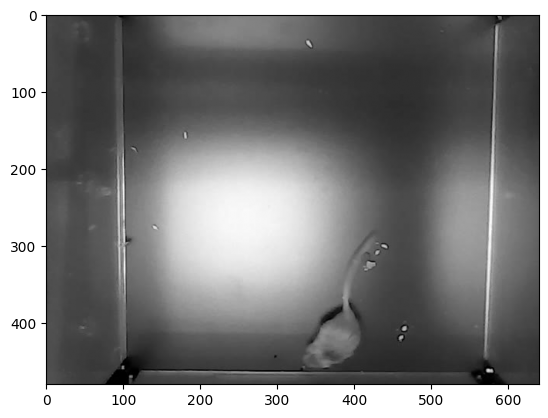

In [11]:
plt.imshow(imgs[3525], cmap='gray')

# Вычитание текущего кадра от фона

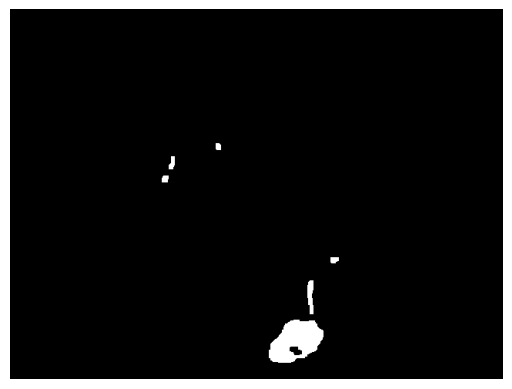

In [12]:
diff_image=cv2.addWeighted(imgs[3525],1,new,-1,0) # Вычисление разности между кадром и моделью фона
# cv2.addWeighted() — функция для взвешенного сложения двух изображений по формуле
# imgs[3525] — текущий кадр (3526-й по счету, так как индексация с 0), 1 — вес (alpha) для первого изображения
# new — модель фона, -1 — вес для второго изображения, 0 — гамма (добавочная константа)

# Там, где кадр совпадает с фоном разность ≈ 0 (темные области)
# Там, где есть движение (в нашем случае мышь) разность > 0 (светлые области)
# Там, где фон ярче кадра возможны отрицательные значения, но OpenCV автоматически обрезает их до 0 при отображении

ret,thresh = cv2.threshold(diff_image, 20, 255,cv2.THRESH_BINARY) # применяет пороговое преобразование к изображению
# Бинаризация изображения (пороговая обработка). 20 — пороговое значение (чувствительность обнаружения движения)
# 255 — максимальное значение для пикселей, превышающих порог, cv2.THRESH_BINARY — тип пороговой обработки (бинарная)

# Возвращает ret — фактически использованное пороговое значение (20), thresh — бинарное изображение, где 
# Пиксели с разностью > 20 => 255 (белый) — движение. Пиксели с разностью ≤ 20 => 0 (черный) — фон

thresh=cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((5,5),np.uint8), iterations=1) # np.ones((5,5), np.uint8) — квадратное ядро 5×5 из единиц
# iterations=1 — операция применяется 1 раз

#cv2.morphologyEx() - функция морфологических операций
#cv2.MORPH_OPEN - операция "открытие" (эрозия + дилатация). Удаляет шум (одиночные белые пиксели, не относящиеся к объекту). Сохраняет форму крупных объектов

thresh=cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8), iterations=1) #cv2.MORPH_CLOSE - операция "закрытие" (дилатация + эрозия)
# Заполняет маленькие дыры внутри объектов. Соединяет близко расположенные фрагменты одного объекта. Сглаживает контуры

plt.imshow(thresh, cmap='gray')

plt.axis('off')

plt.savefig('binary.png', dpi=300, bbox_inches='tight')
plt.show()

# Нахождение центра масс мышки

In [44]:
# Вычисление моментов изображения

# Моменты — это взвешенные средние пикселей изображения. Они описывают геометрические свойства объекта: площадь, центр масс, ориентацию и т.д.
mu=cv2.moments(thresh) # thresh — бинарное изображение, где белые пиксели (255) представляют объект (мышь), черные (0) — фон
mc = (mu['m10'] / (mu['m00'] + 1e-5), mu['m01'] / (mu['m00'] + 1e-5))
# mu — словарь (dictionary), содержащий различные моменты
# Формула для нахождения центра масс: Координата X центра: x = m10 / m00. Координата Y центра: y = m01 / m00

# Моменты m00 - площадь объекта (сумма всех белых пикселей), m10 - сумма координат X всех белых пикселей, m01 - сумма координат Y всех белых пикселей
# 1e-5 = 0.00001. Предотвращает деление на ноль в случае, если объект отсутствует на изображении (m00 = 0)
# Без этого при пустом изображении произошла бы ошибка
mc # упорядоченная последовательность из двух значений: mc[0] — координата X центра масс (столбец), mc[1] — координата Y центра масс (строка)

(363.05135300915214, 406.6989544846406)

# Отрисовка точки

In [14]:
image_test=cv2.copyTo(imgs[3525],imgs[3525]) # Копирование изображения с использованием маски
# cv2.copyTo(src, mask) — копирует изображение src в новую матрицу, но только там, где mask ненулевая
# src = imgs[3525] — исходное изображение (кадр 3526), mask = imgs[3525] — та же картинка используется как маска
# Поскольку маска — это то же самое изображение в оттенках серого, все ненулевые пиксели (практически все, кроме абсолютно черных) будут скопированы
# Это способ создать копию изображения, но с возможностью последующего редактирования, не затрагивая исходные данные

cv2.circle(image_test,(int(mc[0]), int(mc[1])), 5, (0,0,255), -1) # Рисование круга на изображении (отметка центра масс)
# image_tes целевое изображение, (int(mc[0]), int(mc[1])) координаты центра mc[0] — X координата, mc[1] — Y координата центра масс
# 5 - радиус круга в пикселях
# (0,0,255) цвет. Цвет в формате BGR: (0,0,255) = красный (синий=0, зеленый=0, красный=255)
# -1 - толщина линии (отрицательное значение = закрашенный круг)

array([[72, 72, 72, ..., 60, 60, 60],
       [71, 71, 71, ..., 60, 60, 60],
       [71, 71, 71, ..., 60, 60, 60],
       ...,
       [84, 83, 82, ..., 53, 53, 53],
       [84, 84, 82, ..., 53, 53, 53],
       [84, 84, 83, ..., 53, 53, 53]], shape=(480, 640), dtype=uint8)

# Модель фона и отслеживание движение мышки

In [15]:
def mod_fon (arr_image): # Создается функция с именем mod_fon (модель фона), 
    # которая принимает один параметр arr_image — список изображений (кадров видео) в оттенках серого

  mod_fon = np.zeros(arr_image[1].shape, dtype='uint8') # arr_image[1].shape — берет размеры второго изображения в списке (индекс 1)
# Создает начальную модель фона — полностью черное изображение. Постепенно она будет обновляться и адаптироваться к реальному фону
  mom=[None]*len(arr_image) # Создание списка для хранения координат центров масс
# [None]*len(arr_image) — создает список длиной равной количеству кадров, заполненный значениями None
# mom — список, где каждый элемент будет содержать координаты центра масс мыши для соответствующего кадра
    
  for k in range(len(arr_image)-10): # Цикл по кадрам (исключая последние 10)
      # Переменная k — номер текущего кадра (индекс в списке)
    
#Постепенно адаптирует фон к изменениям освещения(Экспоненциальное скользящее среднее)
      
    mod_fon=cv2.addWeighted(arr_image[k],0.5,mod_fon,0.5,0) # Экспоненциальное скользящее среднее (адаптация фона)
    # Новая модель фона = 50% от текущего кадра + 50% от предыдущей модели фона
    # Это экспоненциальное скользящее среднее (EMA) — фон постепенно адаптируется к изменениям
    # Коэффициент 0.5 определяет скорость адаптации: Большой коэффициент (близкий к 1) => быстрая адаптация
    # Маленький коэффициент (близкий к 0) => медленная адаптация
    # Постепенно обновляет модель фона, чтобы учитывать изменения освещения, тени и другие медленные изменения сцены
    # arr_image[k] * 1 + mod_fon * (-1) + 0 Текущий кадр минус модель фона. Выделяет движущиеся объекты (мышь)
      
    diff_image=cv2.addWeighted(arr_image[k],1,mod_fon,-1,0) # Вычисление разности между текущим кадром и моделью фона
    # Там, где кадр совпадает с фоном => разность ≈ 0 (темные области). Там, где есть движение (мышь) => разность > 0 (светлые области)
    # Выделяет движущиеся объекты на статическом фоне
      
    ret,thresh = cv2.threshold(diff_image, 20, 255,cv2.THRESH_BINARY) # Бинаризация (пороговая обработка)
    # diff_image — изображение разности, 20 — пороговое значение (чувствительность обнаружения движения), 255 — макс значение для пикселей выше порога
    # Бинарное изображение thresh, где: Пиксели с разностью > 20 => 255 (белый) — движение, Пиксели с разностью ≤ 20 => 0 (черный) — фон

    mu=cv2.moments(thresh) # Вычисление моментов бинарного изображения
# находим средние X, Y координаты всех пискелей
#  В список mom на позицию k сохраняется кортеж (упорядоченная последовательность) (x, y) — координаты центра масс мыши в текущем кадре
      
    mom[k]=(mu['m10'] / (mu['m00'] + 1e-5), mu['m01'] / (mu['m00'] + 1e-5))
#m00 — это общая масса (сумма всех белых пикселей, площадь объекта)
#m10 — это сумма X-координат всех белых пикселей, умноженных на их яркость
#m01 — это сумма Y-координат всех белых пикселей
      
    if(mom[k][0]==0 and mom[k][1]==0): # Фильтрация скачков (подавление выбросов)
      mom[k]=mom[k-1] # Если центр масс = (0,0), значит объект не обнаружен (m00 = 0 привело к делению на 1e-5 и получению нулевых координат)
# В этом случае используются координаты из предыдущего кадра (mom[k-1]). Это обеспечивает непрерывность трекинга при кратковременной потере объекта
        
#Если мышь передвинулась больше чем на 30 пикселей (слишком быстрое движение). Вместо резкого скачка используются координаты из предыдущего кадра
    if(k!=0): # Убирает ложные срабатывания и выбросы, делая траекторию движения более гладкой
      if((mom[k][0]-mom[k-1][0])>30 or (mom[k][1]-mom[k-1][1])>30):
        mom[k]=mom[k-1]
  return mom # Функция возвращает список mom, содержащий координаты центра масс мыши для каждого кадра (с 0 по len(arr_image)-11) 
# Для последних 10 кадров в списке останутся значения None

In [16]:
data=mod_fon(imgs) # Вызов функции для трекинга движения
# mod_fon(imgs) — вызывается ранее определенная функция, которая: Принимает список всех кадров видео imgs (в оттенках серого)
# Вычисляет адаптивную модель фона с экспоненциальным скользящим средним. Вычисляет адаптивную модель фона с экспоненциальным скользящим средним
# Применяет фильтрацию для устранения ошибок и выбросов. Возвращает список координат центров масс
# data — переменная, которая получает результат выполнения функции
# Это список, где каждый элемент содержит кортеж (x, y) с координатами центра масс для соответствующего кадра

# data[35][1] показывает координату Y мыши на 36-м кадре видео
data[35][1]

212.99999164705915

In [17]:
data

[(318.921063294083, 260.7316723235965),
 (312.8795496549659, 269.40104613364707),
 (267.29684584330096, 277.6078071386599),
 (267.29684584330096, 277.6078071386599),
 (220.83333188997824, 208.66666530283226),
 (220.83333188997824, 208.66666530283226),
 (220.83333188997824, 208.66666530283226),
 (220.83333188997824, 208.66666530283226),
 (186.99999633333343, 194.4999961862746),
 (186.99999633333343, 194.4999961862746),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.9999960392158

In [18]:
imgs[0] # Обращение к первому кадру в списке

array([[33, 33, 33, ..., 28, 28, 28],
       [33, 33, 33, ..., 27, 27, 27],
       [33, 33, 33, ..., 27, 27, 27],
       ...,
       [42, 42, 42, ..., 19, 19, 19],
       [42, 42, 42, ..., 19, 19, 19],
       [42, 42, 42, ..., 19, 19, 19]], shape=(480, 640), dtype=uint8)

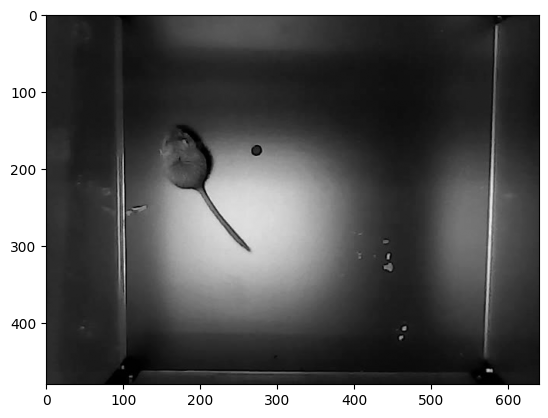

In [19]:
plt.imshow(imgs[0], cmap='gray') # Отображение первого кадра видео в виде изображения

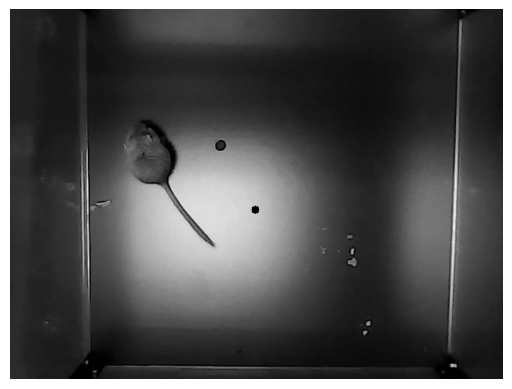

In [21]:
%matplotlib inline  
# делает так, чтобы графики отображались внутри самой ячейки ноутбука. Статические изображения встраиваются прямо в вывод ячейки

k = 0  # номер кадра
image_test = imgs[k].copy() # Создание копии кадра для рисования. imgs[k] — обращение к k-му кадру из списка всех кадров
# .copy() — создает глубокую копию массива NumPy, image_test — новая независимая копия кадра
# cv2.circle() рисует прямо на переданном изображении (изменяет его). Копия позволяет сохранить исходные кадры нетронутыми для дальнейшей обработки
cv2.circle(image_test, (int(data[k][0]), int(data[k][1])), 5, (0,0,255), -1) # Рисование круга на копии кадра
# data[k][0] — X координата центра масс для k-го кадра, data[k][1] — Y координата центра масс для k-го кадра
# int() — округление до целого числа (пиксели не могут быть дробными)
# 5 — радиус круга в пикселях, (0,0,255) — цвет в формате BGR (0,0,255 = красный), -1 — толщина линии (отрицательное значение = закрашенный круг)

# Отображение изображения с нарисованным кругом
# изображение image_test — серое (одноканальное). В результате круг будет отображаться белым цветом (255), а не красным.
plt.imshow(image_test, cmap='gray')
plt.axis('off')  # убирает оси
plt.show()

In [22]:
len(data) # Определение длины списка координат центров масс (кол-во кадров, для которых были вычислены координаты центра масс)

6075

In [23]:
D1=[None]*len(data) # Создание списка для X-координат (будут храниться X-координаты центра масс для каждого кадра)
# Список D1 размером равным количеству кадров в видео, где каждый элемент изначально равен None

D2=[None]*len(data) # Создание списка для Y-координат
for k in range(len(data)-10): # Цикл по кадрам для извлечения координат. 
# range(len(data)-10) — создает последовательность чисел от 0 до len(data)-11 включительно. Переменная k принимает значения: 0, 1, 2, ..., len(data)-11
  print(k) # Вывод номера кадра в консоль
  D1[k] = data[k][0] # Извлечение и сохранение X-координаты
  D2[k] = data[k][1] # Извлечение и сохранение Y-координаты

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

# Построение траектории движения мышки

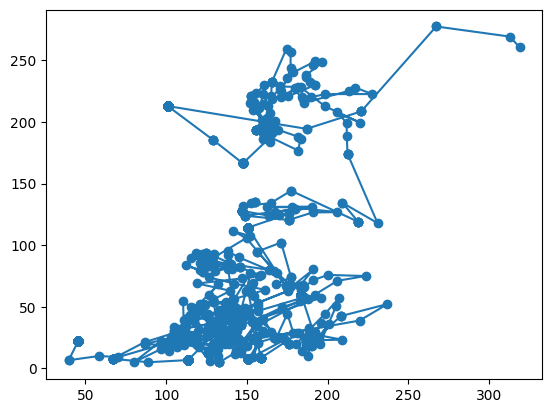

In [24]:
plt.plot(D1, D2, marker='o') # Функция plt.plot() из библиотеки Matplotlib строит линейный график, соединяя точки с координатами (x, y)